# Week 6 — A simple Werewolf villager that learns

*A companion to the Week-6 chapter (`Topics/06.md`). The chapter walks through the algorithm in detail; this notebook runs the smallest possible version of it so you can **see the learning loop in action**.*

## Why two parts?

`Xu et al. (2024)` showed that a prompted LLM agent — one that uses the LLM to *both think and act* — plays Werewolf badly. Their fix is to split the LLM's job in two:

| Role | Done by | Why |
|---|---|---|
| **Propose** candidate actions | LLM | LLMs are good at generating diverse, plausible options from language. |
| **Pick** which candidate to take | A small reinforcement-learning module | LLMs are biased when they *sample* — they over-pick common-in-text actions. |

The motivating diagnostic is small enough to read in one breath. Ask `GPT-4` what the right strategy is in rock-paper-scissors. It explains correctly: play each option about one-third of the time. Then ask it to *actually pick* a move — it picks **rock** far more often than one-third, because the word "rock" appears more often in its training data than "paper" or "scissors." The LLM's *verbal reasoning about the distribution* and its *sampling from the distribution* have come apart.

So the LLM is kept for what it is good at — proposing a diverse set of candidates — and a separate **reinforcement-learning** module is trained to pick among them. The dual structure is the central architectural claim of the paper.

## What this notebook does

We build the smallest possible version of the setup on a Werewolf voting game.

1. **The villager** sees a noisy clue about who the werewolf is.
2. **The LLM** (here, a fixed biased generator) proposes three candidate suspects.
3. **The picker** chooses one of the three to vote for.

We compare:

- A villager who lets the LLM both propose **and** pick — the **bias goes through**, the village loses a lot.
- A villager who lets the LLM propose but uses a **one-line trial-and-error learner** to pick — recovers most of the gap to the optimal strategy.

The learner here is the simplest possible reinforcement learner: *"do more of what worked, less of what didn't."* The full Xu paper uses **PPO** (Proximal Policy Optimization, `Schulman et al. 2017`) — a more sophisticated version with stability tricks for neural-network policies. The chapter (`Topics/06.md` §6) walks through what PPO adds. The shape of the idea is the same.


## The toy game

Real Werewolf has 7 players, hidden roles, night and day phases, discussion, voting, and survival dynamics. We strip it down to one decision so we can see what the learning module is doing.

**Setup.** You are the villager. Each round:

- Four suspects (labelled `0, 1, 2, 3`). One of them is the werewolf, drawn at random.
- You see a **clue** — a noisy probability vector over the four suspects, with most of the mass on the truth.
- The **LLM** proposes **three candidate suspects** for you to consider. (Real implementations would do this through free-text generation; we use a fixed biased distribution so we can isolate what *follows* the proposal.)
- You vote for one of the three.
- If you vote for the werewolf: the village wins, **+1**. Otherwise: the werewolf survives, **−1**.

Each round is one clue, one vote, one piece of feedback. We watch the villager play many rounds and see the win rate climb as the picker learns which suspect to choose when.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_SUSPECTS = 4
SIGNAL_ACCURACY = 0.7   # probability mass on the truth in the noiseless signal


def play_one_game(rng):
    """Draw a werewolf and emit a noisy signal pointing to (mostly) the truth."""
    werewolf = int(rng.integers(N_SUSPECTS))
    sig = np.ones(N_SUSPECTS) * (1 - SIGNAL_ACCURACY) / (N_SUSPECTS - 1)
    sig[werewolf] = SIGNAL_ACCURACY
    sig = 0.75 * sig + 0.25 * rng.dirichlet(np.ones(N_SUSPECTS) * 4.0)
    sig /= sig.sum()
    return sig, werewolf


def reward(action, werewolf):
    return 1.0 if action == werewolf else -1.0


# Quick demo — play one round
rng = np.random.default_rng(0)
sig, ww = play_one_game(rng)
print(f"werewolf is suspect {ww}")
print(f"the clue   = {sig.round(3)}")
print(f"the clue's best guess: suspect {int(sig.argmax())}")
print(f"voting that guess → reward = {reward(int(sig.argmax()), ww):+.0f}")


werewolf is suspect 3
the clue   = [0.124 0.13  0.138 0.608]
the clue's best guess: suspect 3
voting that guess → reward = +1


## The LLM as proposer (with a bias)

In `Xu et al. (2024)`, the LLM is asked to propose three candidate actions per decision. Because the LLM has learned action priors from text — rock more common than paper or scissors; certain names more salient than others — those candidates are not uniformly distributed over the action space, even when the prompt explicitly asks for diversity.

We model this with a `BiasedGenerator` that proposes **three distinct candidate suspects** per round, drawn from a fixed prior over the four suspects. With prior `[0.7, 0.1, 0.1, 0.1]`, suspect 0 appears in the candidate set almost every round; the others appear less often. The generator does *not* see the clue — its bias is **prior to** the evidence.

A pure-LLM villager (no learning) would then pick one of the three by some downstream rule. The picker's job is to choose **the right one** — and to do so against a candidate set that is sometimes missing the correct suspect entirely. That missing-suspect problem will show up in the heatmaps at the end.


In [2]:
class BiasedGenerator:
    """Stand-in for a biased LLM. Proposes 3 distinct candidates from a fixed prior."""

    def __init__(self, prior, n_candidates=3, rng=None):
        self.prior = np.asarray(prior, dtype=float)
        self.prior /= self.prior.sum()
        self.n_candidates = n_candidates
        self.rng = rng or np.random.default_rng()

    def __call__(self):
        cands = self.rng.choice(
            len(self.prior), size=self.n_candidates, replace=False, p=self.prior,
        )
        return [int(c) for c in cands]


BIAS = [0.7, 0.1, 0.1, 0.1]   # suspect 0 is the "rock"
gen = BiasedGenerator(prior=BIAS, rng=np.random.default_rng(0))

# How often does each suspect appear in the candidate set?
counts = np.zeros(N_SUSPECTS)
for _ in range(3000):
    for c in gen():
        counts[c] += 1
freq = counts / 3000

print('how often each suspect appears in the candidate set (3000 calls):')
for i, f in enumerate(freq):
    bar = '█' * int(50 * f)
    print(f'  suspect {i}:  {bar} {f:.0%}')


how often each suspect appears in the candidate set (3000 calls):
  suspect 0:  █████████████████████████████████████████████████ 99%
  suspect 1:  █████████████████████████████████ 67%
  suspect 2:  █████████████████████████████████ 67%
  suspect 3:  █████████████████████████████████ 67%


## Baseline: what happens without learning?

Three reference points before we add the picker.

| Strategy | What the villager does | What it captures |
|---|---|---|
| **random** | pick a proposed suspect uniformly at random | the floor |
| **LLM picks itself** | go with whichever proposed suspect the LLM is most enthusiastic about (highest prior — i.e., suspect 0 if it's in the set) | what an unmodified LLM-only villager would do — the bias goes through |
| **clue-greedy** | go with whichever proposed suspect best matches the clue | the ceiling — the best the villager can do *given* what the LLM proposed |

The gap between "LLM picks itself" and "clue-greedy" is the gap the learning picker has to close.


In [3]:
def simulate(strategy, n_games=5000, seed=42):
    """Run n_games and return the win rate. `strategy(sig, cands, rng) → suspect"""
    rng = np.random.default_rng(seed)
    gen = BiasedGenerator(prior=BIAS, rng=rng)
    wins = 0
    for _ in range(n_games):
        sig, ww = play_one_game(rng)
        cands = gen()
        if strategy(sig, cands, rng) == ww:
            wins += 1
    return wins / n_games


def random_pick(signal, candidates, rng):
    return int(rng.choice(candidates))

def llm_picks_itself(signal, candidates, rng):
    # whichever candidate has the highest prior — i.e., suspect 0 if it's in the set
    return int(candidates[int(np.argmax([BIAS[c] for c in candidates]))])

def clue_greedy(signal, candidates, rng):
    return int(candidates[int(np.argmax([signal[c] for c in candidates]))])


print('Win rates (5000 games each):')
print(f'  random pick      : {simulate(random_pick):.1%}')
print(f'  LLM picks itself : {simulate(llm_picks_itself):.1%}   ← the bias goes through')
print(f'  clue-greedy    : {simulate(clue_greedy):.1%}   ← the ceiling we want to reach')


Win rates (5000 games each):
  random pick      : 24.7%


  LLM picks itself : 23.4%   ← the bias goes through

  clue-greedy    : 74.6%   ← the ceiling we want to reach


## The picker — a learning agent

This is the second half of `Xu`'s dual architecture. The LLM has already done its job: it proposed three candidate suspects. The picker's job is to choose **the right one**.

The idea is the oldest one in behavioural psychology — Thorndike's *law of effect* (`Thorndike 1911`): actions followed by reward become more likely; actions followed by punishment become less so. The same shape appears in experimental economics under the name "reinforcement learning in games" (`Roth & Erev 1995`), and in modern AI as the basis of everything from Q-learning to PPO.

Our picker keeps a small table — one entry per `(situation, action)` pair — storing the average reward it has seen for taking that action in that situation. Each round it:

1. Reads the clue and identifies the **situation** (we use "which suspect the clue points to most").
2. Looks at the LLM's three proposed candidates and picks the one with the **highest expected reward**, with a small probability $\epsilon$ of exploring at random instead.
3. Votes, observes the reward, and **nudges** the corresponding table entry toward what it just observed.

The "nudge" is one line of code:

$$\text{scores}[s, a] \;\leftarrow\; \text{scores}[s, a] \;+\; \alpha \cdot \big( \text{reward} - \text{scores}[s, a] \big)$$

Where $\alpha$ is the *learning rate* (we use $\alpha = 0.01$ below). Over many rounds, `scores[s, a]` converges to the expected reward of voting for suspect $a$ when the clue points to suspect $s$.

This is the simplest possible reinforcement learner. `Xu et al. (2024)` use **PPO** instead — a policy-gradient method that adds importance sampling, advantage estimation, and a clipped surrogate objective for stability when the policy is a neural network. The chapter walks through what each piece adds. For this notebook, the one-line update above is enough to see the central effect.


In [4]:
class LearningAgent:
    """Trial-and-error agent — tracks expected reward per (situation, action)."""

    def __init__(self, learning_rate=0.01, exploration=0.2, rng=None):
        self.rng = rng or np.random.default_rng()
        # initialise with tiny noise so argmax-of-zeros doesn't always pick candidates[0]
        self.scores = 1e-4 * self.rng.standard_normal((N_SUSPECTS, N_SUSPECTS))
        self.lr = learning_rate
        self.eps = exploration

    def vote(self, signal, candidates):
        situation = int(signal.argmax())
        if self.rng.random() < self.eps:
            action = int(self.rng.choice(candidates))                # explore
        else:
            scores = [self.scores[situation, c] for c in candidates]
            action = int(candidates[int(np.argmax(scores))])         # exploit
        return situation, action

    def learn(self, situation, action, reward):
        # the one-line update: nudge the score toward the observed reward
        self.scores[situation, action] += self.lr * (reward - self.scores[situation, action])


## Running the agent

Eight thousand rounds. We log every (round, situation, action, werewolf, reward) so we can plot both the learning curve and the policy shift.


In [5]:
def train(n_games=4000, seed=0):
    rng = np.random.default_rng(seed)
    gen = BiasedGenerator(prior=BIAS, rng=rng)
    agent = LearningAgent(rng=rng)

    log = []
    for t in range(n_games):
        sig, ww = play_one_game(rng)
        cands = gen()
        situation, action = agent.vote(sig, cands)
        r = reward(action, ww)
        agent.learn(situation, action, r)
        log.append((t, situation, action, ww, r))
    return agent, log


agent, log = train(n_games=4000)
wins = np.array([r > 0 for (_, _, _, _, r) in log])

# Early-game climb — the simple update converges within a few dozen games
print('win rate over the early games (the climb):')
for lo, hi in [(0, 10), (10, 30), (30, 100), (100, 500), (500, 4000)]:
    bar = '█' * int(50 * wins[lo:hi].mean())
    print(f'  games {lo:>4}–{hi:<4}:  {bar} {wins[lo:hi].mean():.0%}')


win rate over the early games (the climb):
  games    0–10  :  █████████████████████████ 50%
  games   10–30  :  ████████████████████████████████ 65%
  games   30–100 :  ███████████████████████████████ 63%
  games  100–500 :  ██████████████████████████████████ 69%
  games  500–4000:  ████████████████████████████████ 65%


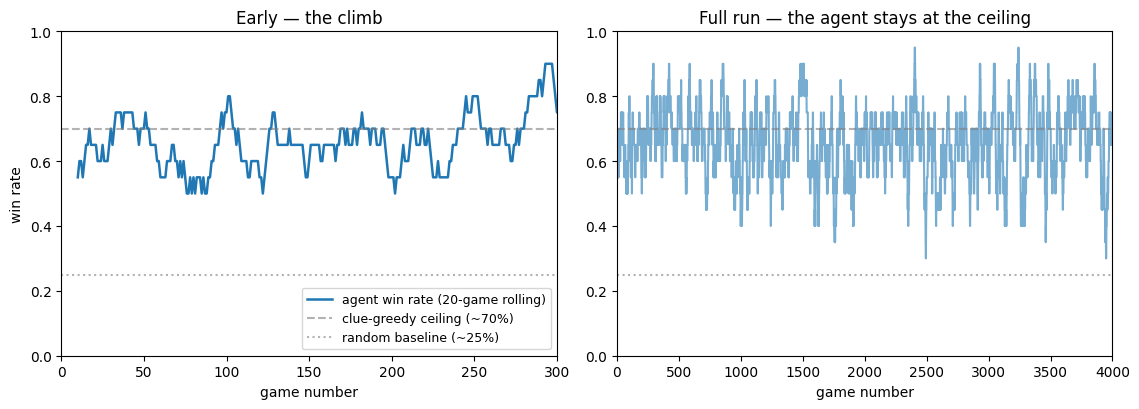

In [6]:
# Learning curve — small window so the climb is visible
window = 20
rolling = np.convolve(wins.astype(float), np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# left: zoom in on the early games where learning happens
axes[0].plot(np.arange(len(rolling)) + window // 2, rolling, linewidth=1.8, color='C0',
             label=f'agent win rate ({window}-game rolling)')
axes[0].axhline(0.70, color='gray', linestyle='--', alpha=0.6, label='clue-greedy ceiling (~70%)')
axes[0].axhline(0.25, color='gray', linestyle=':',  alpha=0.6, label='random baseline (~25%)')
axes[0].set_xlim(0, 300)
axes[0].set_xlabel('game number')
axes[0].set_ylabel('win rate')
axes[0].set_title('Early — the climb')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=9)

# right: full run shows that the agent then sits at the ceiling
axes[1].plot(np.arange(len(rolling)) + window // 2, rolling, linewidth=1.5, color='C0', alpha=0.6)
axes[1].axhline(0.70, color='gray', linestyle='--', alpha=0.6)
axes[1].axhline(0.25, color='gray', linestyle=':',  alpha=0.6)
axes[1].set_xlim(0, 4000)
axes[1].set_xlabel('game number')
axes[1].set_title('Full run — the agent stays at the ceiling')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## What did the picker actually learn?

The plot above shows it gets better fast — the climb is mostly done within the first 30 or so games. With only 4 situations × 4 candidates = 16 cells in the score table, each one needs only a handful of feedback observations to settle. In a real Werewolf agent — `Xu et al. (2024)` with neural networks, continuous state, and thousands of (situation, action) pairs — convergence takes orders of magnitude longer.

To see *what* the picker learned, the heatmaps below compare two villagers on the same setup:

- **Left:** the LLM-only baseline — the villager who lets the LLM also do the picking. No learning at all.
- **Right:** the trained picker — the villager after 4000 rounds of trial-and-error feedback.

Read each row as: *"when the clue pointed to suspect $s$, what did the villager vote?"* A villager that has learned to use the clue should have most of the mass on the **diagonal**.


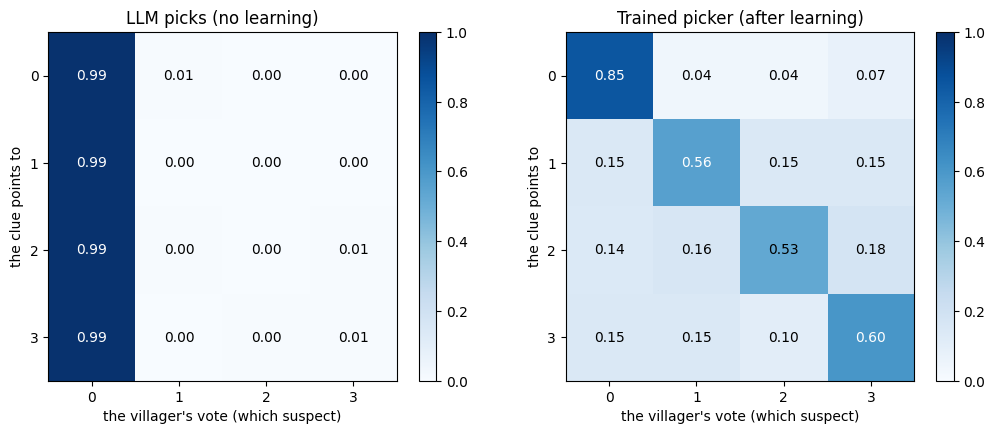

In [7]:
def freq_table(log_entries, t_lo, t_hi):
    """For rounds in [t_lo, t_hi), compute P(vote | clue-argmax)."""
    table = np.zeros((N_SUSPECTS, N_SUSPECTS))
    counts = np.zeros(N_SUSPECTS)
    for t, s, a, ww, r in log_entries:
        if t_lo <= t < t_hi:
            table[s, a] += 1
            counts[s] += 1
    return table / np.clip(counts[:, None], 1, None)


def behaviour_log(strategy, n_games=4000, seed=1):
    """Run a non-learning strategy and produce a behaviour log in the same format."""
    rng = np.random.default_rng(seed)
    gen = BiasedGenerator(prior=BIAS, rng=rng)
    entries = []
    for t in range(n_games):
        sig, ww = play_one_game(rng)
        cands = gen()
        s = int(sig.argmax())
        a = strategy(sig, cands, rng)
        entries.append((t, s, a, ww, 1.0 if a == ww else -1.0))
    return entries


# LLM-only baseline: same villager, same clues, same LLM proposals — but no learning
llm_only_log = behaviour_log(llm_picks_itself, n_games=4000)

# The two heatmaps we want to compare
llm_only_table = freq_table(llm_only_log, 0, 4000)         # whole run
trained_table  = freq_table(log,          3800, 4000)      # after convergence

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, tab, title in zip(
    axes,
    [llm_only_table, trained_table],
    ['LLM picks (no learning)', 'Trained picker (after learning)'],
):
    im = ax.imshow(tab, cmap='Blues', vmin=0, vmax=1)
    ax.set_xlabel('the villager\'s vote (which suspect)')
    ax.set_ylabel('the clue points to')
    ax.set_title(title)
    ax.set_xticks(range(N_SUSPECTS))
    ax.set_yticks(range(N_SUSPECTS))
    for i in range(N_SUSPECTS):
        for j in range(N_SUSPECTS):
            ax.text(j, i, f'{tab[i, j]:.2f}', ha='center', va='center',
                    fontsize=10, color='black' if tab[i, j] < 0.55 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## Reading the heatmaps

**Rows** = situations: "the clue points to suspect $s$."
**Columns** = the villager's vote: "the villager voted for suspect $a$."
A cell is the fraction of rounds where that combination happened.

**Left — LLM picks (no learning).** Look at the columns: nearly everything is in **column 0**. Whatever the clue says, the villager votes for suspect 0. That is the rock-paper-scissors bias going through: the LLM proposes suspect 0 in ~99% of rounds, and its own picking rule says "go with the highest-prior candidate" — so it picks suspect 0 whenever it is available. Suspects 1, 2, and 3 occasionally get votes only when suspect 0 happens not to be in the proposed set. The diagonal is essentially absent.

**Right — Trained picker.** A clear diagonal: when the clue points to suspect $s$, the villager votes for $s$ most of the time. This is the picker doing the thing the LLM-only baseline could not — *using the clue* instead of inheriting the LLM's enthusiasm for suspect 0.

**The off-diagonal mass that still remains in the trained heatmap** is the most interesting part. Look at column 0 in the bottom three rows: even after convergence, the villager votes for suspect 0 about 15% of the time when the clue points to suspect 1, 2, or 3. That mass is **structural**, not a learning failure.

The LLM proposes suspect 0 in ~99% of rounds but proposes suspects 1, 2, 3 only ~67% of the time each. So in ~33% of the rounds where the clue points to (say) suspect 2, the LLM did *not* propose suspect 2 — and the villager is forced to vote for whoever is in the proposed set. That fallback is almost always suspect 0. The picker is doing its job; it cannot vote for someone the LLM did not put on the ballot.

This is the bound `Xu et al. (2024)` identify in their §5.4 ablation: **the system's ceiling is set by the candidate generator's diversity, not by the picker's competence**. Improving the picker (better PPO, more training, larger network) cannot fix the column-0 fallback. Only improving the LLM's proposal diversity can. *That* is the practical consequence of the dual structure — each half has its own failure mode, and the two halves need different fixes.


## What this notebook showed — and what it didn't

**What we saw.**

1. An LLM-style agent that picks among its own biased candidates inherits the bias — its votes pile up on suspect 0 regardless of what the signal says, and its win rate hovers near the random-pick floor.
2. A one-line learning update — *nudge the score toward the observed reward* — lets the agent recover most of the gap to the clue-greedy ceiling within a few thousand rounds.
3. The before/after action distribution shows the agent shifting from biased to signal-following voting behaviour.

**What we left out.**

1. **The real algorithm.** `Xu et al. (2024)` use **MAPPO** — multi-agent PPO (`Yu et al. 2022`) — a policy-gradient method with stability tricks designed for neural-network policies. Our one-line nudge is the simplest cousin in the same family. The chapter (`Topics/06.md` §6) walks through what PPO adds: importance sampling, advantage estimation, the clipped surrogate.
2. **The LLM.** The biased generator is a fixed distribution. A real LLM's bias depends on the prompt, decoding settings, and reasoning trace, and shifts from decision to decision.
3. **The full game.** No discussion turns, no hidden-role inference, no night/day cycle, no opponents, no role asymmetry. Just one signal, one vote, one feedback.

**Two connections to the rest of the week.**

- `Dolgopolov (2024)` studies the same trial-and-error learning shape in an iterated Prisoner's Dilemma, but works out **analytically** when it converges to cooperation versus defection. Our notebook is a numerical simulation of one such learner; Dolgopolov is the closed-form characterisation.
- `McKee et al. (2023)` uses the deep-RL form of the same idea, but puts the learner **outside** the game — it learns to design network rewires that get groups of humans to cooperate, rather than to play the game itself.

**A question to bring to class.**

The agent's ceiling here is set by *what the LLM proposes*, not *what the learning module does with it*. When the candidate set never contains the signalled suspect, the learner cannot recover that round. In `Xu`'s full system the candidate generator is also an LLM — same upstream bound. *Where does that bound bite hardest in the paper's results, and which extension of the system would push it furthest?* The answer points at the candidate generator, not the selector — which is precisely the ablation `Xu et al. (2024)` ran in §5.4.


## References

- `Xu, Yu, Fang, Wang & Wu (2024)` — Language Agents with Reinforcement Learning for Strategic Play in the Werewolf Game. ICML 2024. arXiv:2310.18940.
- `Schulman, Wolski, Dhariwal, Radford & Klimov (2017)` — Proximal Policy Optimization Algorithms. arXiv:1707.06347.
- `Yu, Velu, Vinitsky, Gao, Wang, Bayen & Wu (2022)` — The Surprising Effectiveness of PPO in Cooperative Multi-Agent Games. NeurIPS.
- `Roth & Erev (1995)` — Learning in extensive-form games. *Games and Economic Behavior*.
- `Thorndike (1911)` — *Animal Intelligence*. The law of effect.
- `Dolgopolov (2024)` — Reinforcement Learning in a Prisoner's Dilemma. *Games and Economic Behavior*.
- `McKee, Tacchetti, Bakker, Balaguer, Campbell-Gillingham, Everett & Botvinick (2023)` — Scaffolding cooperation in human groups with deep reinforcement learning. *Nature Human Behaviour*.
